# EfficientNet-B0

**Objective**: This notebook tests EfficientNet-B0 to see if the EfficientNet architecture itself is the issue on this task, or if B3 was just too complex for the small dataset.

**Architecture Changes**:
| Component | Previous iteration (EfficientNet-B3) | This iteration (EfficientNet-B0) |
|---|---|---|
| Parameters | ~12M | ~5.3M |
| Native input size | 300×300 | 224×224 |

**Hypothesis**: EfficientNet-B3 consistently underperformed ResNet-18 Unfreeze. The hypothesis is that B3 is too complex for the ~7,800 image dataset and overfits. B0 is smaller (~5.3M params) and uses 224×224 natively. If B0 still underperforms, the issue is the EfficientNet architecture itself on this task, not just scale.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_train_transforms
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_efficientnet(variant='b0', num_classes=1, freeze_backbone=False).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 20

L1_LAMBDA = 0.0
L2_LAMBDA = 0.0
dropout = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {dropout}')

Trainable params: 4,008,829 / 4,008,829
L1 lambda: 0.0 | L2 lambda: 0.0 | Dropout: 0.0


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), str(ROOT / 'models/efficientnet_b0_best.pth'))
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/20]
  Train | Loss: 0.8668, Bal Acc: 0.7664, Recall: 0.8655, F2: 0.5721, AUC: 0.8511
  Val   | Loss: 0.7392, Bal Acc: 0.8018, Recall: 0.8983, F2: 0.6298, AUC: 0.9039
  -> Saved best model (val AUC: 0.9039)


Epoch [2/20]
  Train | Loss: 0.6459, Bal Acc: 0.8369, Recall: 0.8757, F2: 0.6723, AUC: 0.9182
  Val   | Loss: 0.6687, Bal Acc: 0.8225, Recall: 0.8771, F2: 0.6609, AUC: 0.9156
  -> Saved best model (val AUC: 0.9156)


Epoch [3/20]
  Train | Loss: 0.5020, Bal Acc: 0.8784, Recall: 0.8985, F2: 0.7428, AUC: 0.9516
  Val   | Loss: 0.7240, Bal Acc: 0.8282, Recall: 0.9025, F2: 0.6669, AUC: 0.9048


Epoch [4/20]
  Train | Loss: 0.4069, Bal Acc: 0.9097, Recall: 0.9373, F2: 0.7953, AUC: 0.9679
  Val   | Loss: 0.8011, Bal Acc: 0.8229, Recall: 0.7542, F2: 0.6763, AUC: 0.9096


Epoch [5/20]
  Train | Loss: 0.3454, Bal Acc: 0.9230, Recall: 0.9396, F2: 0.8243, AUC: 0.9765
  Val   | Loss: 0.9057, Bal Acc: 0.8236, Recall: 0.7966, F2: 0.6719, AUC: 0.9002


...

Epoch [16/20]
  Train | Loss: 0.0942, Bal Acc: 0.9806, Recall: 0.9852, F2: 0.9511, AUC: 0.9983
  Val   | Loss: 1.4847, Bal Acc: 0.8150, Recall: 0.7161, F2: 0.6669, AUC: 0.9036


Epoch [17/20]
  Train | Loss: 0.0892, Bal Acc: 0.9805, Recall: 0.9829, F2: 0.9523, AUC: 0.9982
  Val   | Loss: 1.5308, Bal Acc: 0.8097, Recall: 0.7034, F2: 0.6587, AUC: 0.9000


Epoch [18/20]
  Train | Loss: 0.1052, Bal Acc: 0.9783, Recall: 0.9818, F2: 0.9466, AUC: 0.9977
  Val   | Loss: 1.4172, Bal Acc: 0.8124, Recall: 0.7203, F2: 0.6615, AUC: 0.9012


Epoch [19/20]
  Train | Loss: 0.0674, Bal Acc: 0.9872, Recall: 0.9909, F2: 0.9668, AUC: 0.9990
  Val   | Loss: 1.4644, Bal Acc: 0.8219, Recall: 0.7288, F2: 0.6782, AUC: 0.9115


Epoch [20/20]
  Train | Loss: 0.0818, Bal Acc: 0.9811, Recall: 0.9806, F2: 0.9558, AUC: 0.9987
  Val   | Loss: 1.4518, Bal Acc: 0.8153, Recall: 0.7246, F2: 0.6664, AUC: 0.9098


## Plot Train and Validation Curves

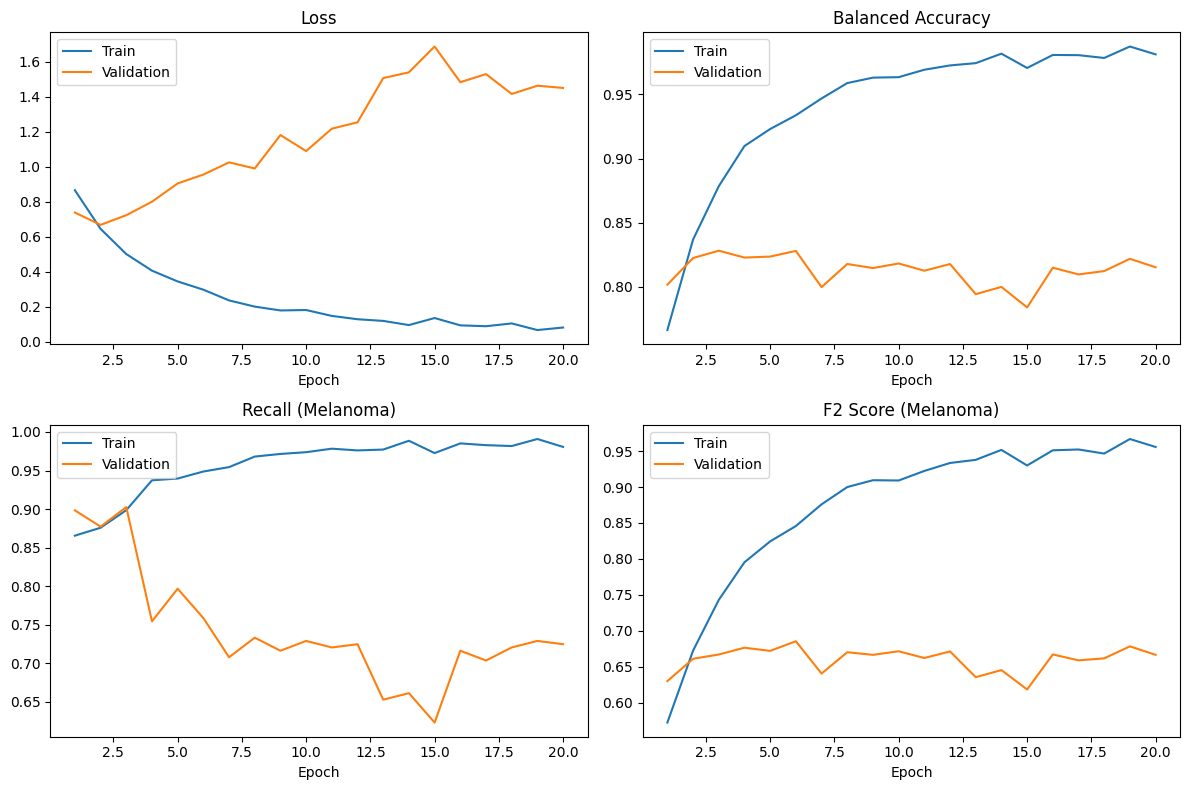

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/efficientnet_b0_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.63 | Val F2: 0.6716


## Test Set Evaluation

Threshold:          0.63
AUC-ROC:            0.9077
Balanced Accuracy:  0.8097
F2 Score:           0.6455

              precision    recall  f1-score   support

Non-Melanoma     0.9680    0.8358    0.8971      1340
    Melanoma     0.3785    0.7836    0.5105       171

    accuracy                         0.8299      1511
   macro avg     0.6733    0.8097    0.7038      1511
weighted avg     0.9013    0.8299    0.8533      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


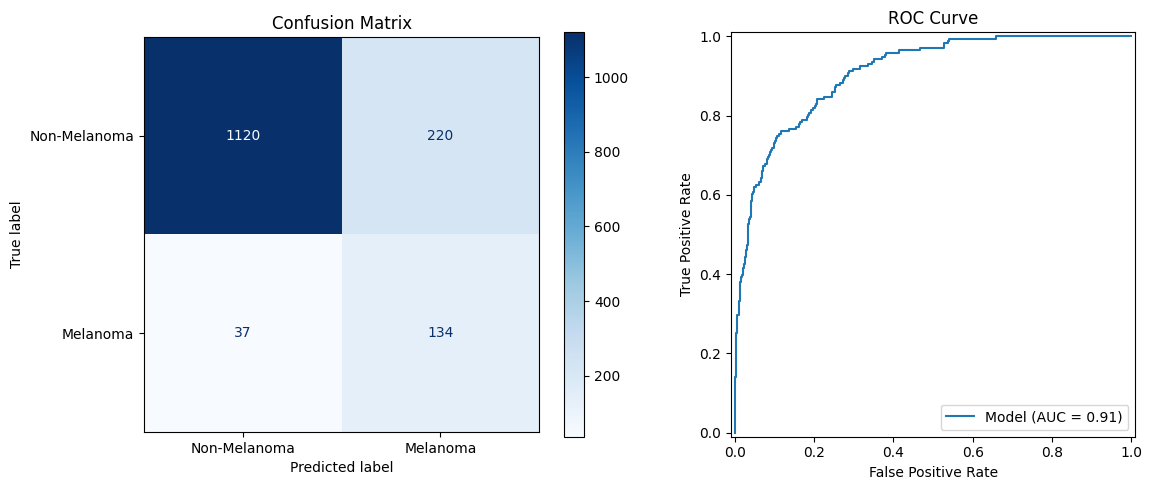

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)